# Slanted Channel Post-Processing: Analytical vs Numerical Solutions

Compare numerical simulations to analytical solution for tilted parabolic pipe flow.
Analyze error convergence with grid refinement and wall boundary errors.

## Load Modules and Data

In [16]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import yt
import warnings
warnings.filterwarnings('ignore')

print('Modules loaded')


Modules loaded


In [17]:
# Physical parameters
channelHeight = 1.0
maxVelocity = 1.0
theta_deg = 7.5
theta_rad = np.deg2rad(theta_deg)

rootDir = '/Users/dmontgo2/Documents/Kynema/estuary_hfm_mmsei/validation/single_phase_laminar_slanted/cases'
figureDir = '/Users/dmontgo2/Documents/Kynema/estuary_hfm_mmsei/validation/single_phase_laminar_slanted/figures'

case_specs = [('slanted-ibfm-64', 64), ('slanted-ibfm-128', 128), ('slanted-ibfm-256', 256), ('slanted-ibfm-512', 512)]

# Find available cases with data
case_paths, case_resolutions, valid_cases = [], [], []
for case_name, resolution in case_specs:
    case_dir = os.path.join(rootDir, case_name)
    if os.path.exists(case_dir):
        plt_dirs = sorted([d for d in os.listdir(case_dir) if d.startswith('plt')])
        if plt_dirs:
            case_paths.append(os.path.join(case_dir, plt_dirs[-1]))
            case_resolutions.append(resolution)
            valid_cases.append(case_name)
            print(f'{case_name}: {plt_dirs[-1]}')

nCases = len(valid_cases)
print(f'\nLoading {nCases} cases')

slanted-ibfm-64: plt02000
slanted-ibfm-128: plt02000
slanted-ibfm-256: plt02000
slanted-ibfm-512: plt01200

Loading 4 cases


In [18]:
# Load datasets using yt
ds_list, x, y, z, nx, ny, nz, dx, dy, dz, u, v, w, p = [], [], [], [], [], [], [], [], [], [], [], [], [], []

for case_idx, case_path in enumerate(case_paths):
    print(f'Loading {valid_cases[case_idx]}...')
    try:
        # Load with yt
        ds_yt = yt.load(case_path)
        ds_list.append(ds_yt)
        
        # Get grid information
        dims = ds_yt.domain_dimensions
        
        print(f'  Dimensions: {dims}')
        
        # Use covering_grid to get structured data directly
        cube = ds_yt.covering_grid(level=0, left_edge=ds_yt.domain_left_edge, dims=dims)
        
        # Extract coordinate arrays (automatically cell-centered)
        x_arr = cube["index", "x"].d[:, 0, 0]  # Extract 1D by taking first slice in y,z
        y_arr = cube["index", "y"].d[0, :, 0]  # Extract 1D by taking first slice in x,z
        z_arr = cube["index", "z"].d[0, 0, :]  # Extract 1D by taking first slice in x,y
        
        x.append(x_arr)
        y.append(y_arr)
        z.append(z_arr)
        
        nx.append(dims[0])
        ny.append(dims[1])
        nz.append(dims[2])
        
        dx.append(x_arr[1] - x_arr[0] if len(x_arr) > 1 else 0)
        dy.append(y_arr[1] - y_arr[0] if len(y_arr) > 1 else 0)
        dz.append(z_arr[1] - z_arr[0] if len(z_arr) > 1 else 0)
        
        # Extract 3D field data
        u_data_3d = cube["velocityx"].d
        v_data_3d = cube["velocityy"].d
        w_data_3d = cube["velocityz"].d
        p_data_3d = cube["p"].d
        
        u.append(u_data_3d)
        v.append(v_data_3d)
        w.append(w_data_3d)
        p.append(p_data_3d)
        
        print(f'  Grid spacing: dx={dx[-1]:.6f}, dy={dy[-1]:.6f}, dz={dz[-1]:.6f}')
        print(f'  Velocity range: u=[{u_data_3d.min():.4f}, {u_data_3d.max():.4f}]\n')
        
    except Exception as e:
        print(f'  Error: {e}\n')
        import traceback
        traceback.print_exc()

nCases = len(ds_list)
print(f'Loaded {nCases} cases\n')

yt : [INFO     ] 2026-05-27 10:00:36,353 Parameters: current_time              = 10.000000000000163
yt : [INFO     ] 2026-05-27 10:00:36,353 Parameters: domain_dimensions         = [64  4 32]
yt : [INFO     ] 2026-05-27 10:00:36,354 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-05-27 10:00:36,354 Parameters: domain_right_edge         = [4.     0.0625 2.    ]
yt : [INFO     ] 2026-05-27 10:00:36,452 Parameters: current_time              = 10.000000000000163
yt : [INFO     ] 2026-05-27 10:00:36,452 Parameters: domain_dimensions         = [128   4  64]
yt : [INFO     ] 2026-05-27 10:00:36,453 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-05-27 10:00:36,453 Parameters: domain_right_edge         = [4.     0.0625 2.    ]


Loading slanted-ibfm-64...
  Dimensions: [64  4 32]
  Grid spacing: dx=0.062500, dy=0.015625, dz=0.062500
  Velocity range: u=[-0.0106, 0.9899]

Loading slanted-ibfm-128...
  Dimensions: [128   4  64]


yt : [INFO     ] 2026-05-27 10:00:36,562 Parameters: current_time              = 10.000000000000163
yt : [INFO     ] 2026-05-27 10:00:36,563 Parameters: domain_dimensions         = [256   4 128]
yt : [INFO     ] 2026-05-27 10:00:36,563 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-05-27 10:00:36,564 Parameters: domain_right_edge         = [4.     0.0625 2.    ]
yt : [INFO     ] 2026-05-27 10:00:36,707 Parameters: current_time              = 5.999999999999894
yt : [INFO     ] 2026-05-27 10:00:36,707 Parameters: domain_dimensions         = [512   8 256]
yt : [INFO     ] 2026-05-27 10:00:36,707 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-05-27 10:00:36,708 Parameters: domain_right_edge         = [4.     0.0625 2.    ]


  Grid spacing: dx=0.031250, dy=0.015625, dz=0.031250
  Velocity range: u=[-0.0084, 0.9914]

Loading slanted-ibfm-256...
  Dimensions: [256   4 128]
  Grid spacing: dx=0.015625, dy=0.015625, dz=0.015625
  Velocity range: u=[-0.0093, 0.9914]

Loading slanted-ibfm-512...
  Dimensions: [512   8 256]
  Grid spacing: dx=0.007812, dy=0.007812, dz=0.007812
  Velocity range: u=[-0.0093, 0.9914]

Loaded 4 cases



### Plots of Loaded Data

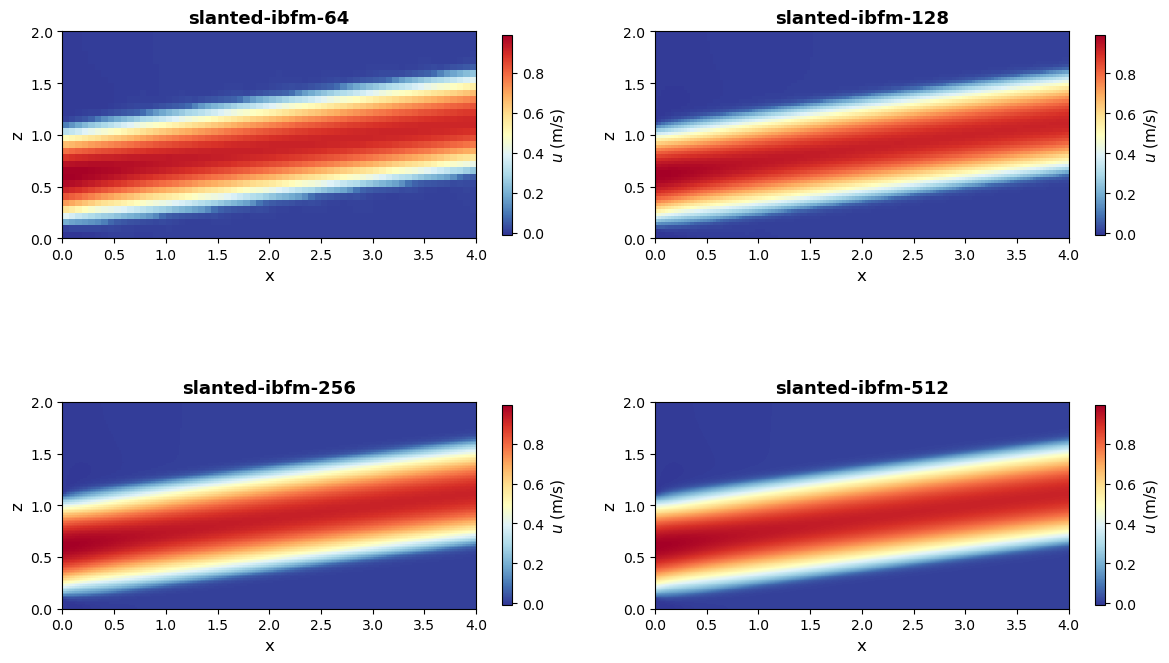

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for case_idx in range(4):
    ax = axes[case_idx]
    
    if case_idx < nCases:
        # Get middle y-index
        mid_y_idx = ny[case_idx] // 2
        
        # Extract 2D slice at middle y
        x_2d = x[case_idx]
        z_2d = z[case_idx]
        u_2d = u[case_idx][:, mid_y_idx, :]
        
        # Create 2D coordinate meshes for pcolormesh
        X_mesh, Z_mesh = np.meshgrid(x_2d, z_2d, indexing='ij')
        
        # Plot with "RdYlBu_r" colormap using pcolormesh
        mesh = ax.pcolormesh(X_mesh, Z_mesh, u_2d, cmap="RdYlBu_r", shading="auto")
        cbar = plt.colorbar(mesh, ax=ax, shrink=0.5)
        cbar.set_label('$u$ (m/s)', fontsize=11)
        
        ax.set_xlabel('x', fontsize=12)
        ax.set_ylabel('z', fontsize=12)
        ax.set_title(f'{valid_cases[case_idx]}', fontsize=13, fontweight='bold')
        ax.set_aspect('equal')
    else:
        ax.axis('off')

plt.tight_layout()
plt.savefig(f'{figureDir}/loaded_velocity_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

## Define Analytical Solution

The axial velocity (along the tilted flow direction) for parabolic pipe flow is:

$$u(r) = U_{\max} \left(1 - \left(\frac{2r}{H}\right)^2\right)$$

where the perpendicular distance from the tilted centerline is:

$$r = |x\sin\theta - (z-s)\cos\theta|$$

The centerline is shifted vertically by $s$ in the $z$-direction, and rotated at an angle $\theta$ about the point $(0, s)$ in the $x$-$z$ plane. Flow is along the tilted centerline, decomposed into components:

$$u_x = u \cos\theta, \quad u_z = u \sin\theta$$

In [20]:
def radial_distance_from_axis(x_coord, z_coord, s, theta):
    """Perpendicular distance from tilted centerline"""
    return np.abs((z_coord - s) * np.cos(theta) - x_coord * np.sin(theta))

def velocity_profile_analytical(r, U_max=1.0, H=1.0):
    """Parabolic profile: u(r) = U_max * (1 - (2r/H)^2)"""
    return U_max * np.maximum(0.0, 1.0 - (2.0 * r / H)**2)

def get_analytical_solution_grid(case_idx):
    s = channelHeight / (2.0 * np.cos(theta_rad)) + channelHeight / 10.0
    X, Y, Z = np.meshgrid(x[case_idx], y[case_idx], z[case_idx], indexing='ij')
    r = radial_distance_from_axis(X, Z, s, theta_rad)
    u_mag = velocity_profile_analytical(r, maxVelocity, channelHeight)
    
    # Set solution to zero outside the channel
    channel_mask = r <= (channelHeight / 2.0)
    u_mag[~channel_mask] = 0.0
    
    u_exact = u_mag * np.cos(theta_rad)
    w_exact = u_mag * np.sin(theta_rad)
    v_exact = np.zeros_like(u_exact)
    return u_exact, v_exact, w_exact, r, s

def axial_velocity(u, w, theta):
    """Compute axial velocity along the tilted flow direction"""
    return u * np.cos(theta) + w * np.sin(theta)

# Compute analytical solutions
u_exact, v_exact, w_exact, r_dist, channel_shift = [], [], [], [], []
for case_idx in range(nCases):
    u_a, v_a, w_a, r, s = get_analytical_solution_grid(case_idx)
    u_exact.append(u_a)
    v_exact.append(v_a)
    w_exact.append(w_a)
    r_dist.append(r)
    channel_shift.append(s)

print('Analytical solutions computed')


Analytical solutions computed


## Plot Geometry Setup

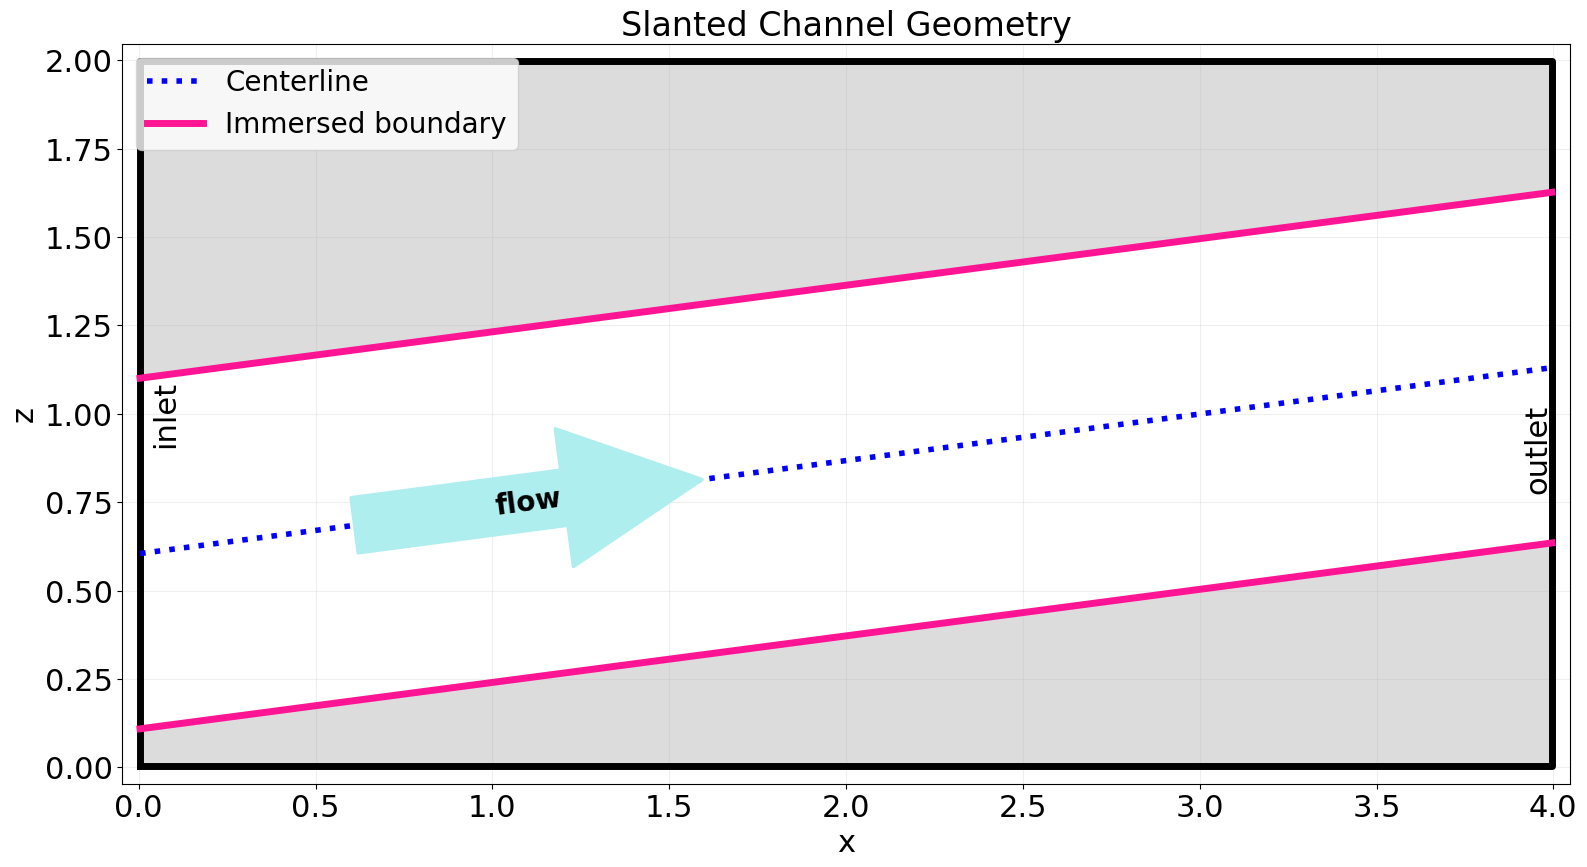

Geometry visualization complete



In [21]:
# Create geometry visualization
fig, ax = plt.subplots(figsize=(16, 10))
fontSize = 22
tol = 0.05

x_min = min([np.min(x[i]) for i in range(nCases)])
x_max = max([np.max(x[i]) for i in range(nCases)])
z_min = min([np.min(z[i]) for i in range(nCases)])
z_max = max([np.max(z[i]) for i in range(nCases)])

# Domain outline
ax.plot([x_min, x_max, x_max, x_min, x_min], [z_min, z_min, z_max, z_max, z_min], 'k-', linewidth=5)

# Channel geometry
s = channel_shift[0]
x_centerline = np.linspace(x_min, x_max, 100)
z_centerline = s + x_centerline * np.tan(theta_rad)
ax.plot(x_centerline, z_centerline, 'b:', linewidth=4, label='Centerline')

# Channel walls and immersed boundary regions
perp_offset = channelHeight / 2.0
x_boundary_full = np.linspace(x_min, x_max, 100)

# Lower channel boundary
z_lower = s + x_boundary_full * np.tan(theta_rad) - perp_offset * np.cos(theta_rad)
# Upper channel boundary
z_upper = s + x_boundary_full * np.tan(theta_rad) + perp_offset * np.cos(theta_rad)

# Draw immersed boundary walls in deeppink
ax.plot(x_boundary_full, z_lower, color='deeppink', linewidth=5, label='Immersed boundary')
ax.plot(x_boundary_full, z_upper, color='deeppink', linewidth=5)

# Fill regions outside the channel with grey (gainsboro)
# Lower solid region - from domain bottom to lower boundary
lower_x = np.concatenate([x_boundary_full, [x_max, x_min]])
lower_z = np.concatenate([z_lower, [z_min, z_min]])
lower_polygon = plt.matplotlib.patches.Polygon(list(zip(lower_x, lower_z)), 
                                 facecolor='gainsboro', edgecolor='none', alpha=1.0, zorder=0)
ax.add_patch(lower_polygon)

# Upper solid region - from upper boundary to domain top
upper_x = np.concatenate([x_boundary_full, [x_max, x_min]])
upper_z = np.concatenate([z_upper, [z_max, z_max]])
upper_polygon = plt.matplotlib.patches.Polygon(list(zip(upper_x, upper_z)), 
                                 facecolor='gainsboro', edgecolor='none', alpha=1.0, zorder=0)
ax.add_patch(upper_polygon)

# Flow direction arrow (paleturquoise)
arrow_x_start = x_min + 0.15 * (x_max - x_min)
arrow_z_start = s + arrow_x_start * np.tan(theta_rad)
arrow_x_end = arrow_x_start + 0.25 * (x_max - x_min)
arrow_z_end = s + arrow_x_end * np.tan(theta_rad)

arrow = plt.matplotlib.patches.FancyArrowPatch((arrow_x_start, arrow_z_start), (arrow_x_end, arrow_z_end),
                                 mutation_scale=200, facecolor='paleturquoise', edgecolor='paleturquoise', linewidth=2.5, zorder=2)
ax.add_patch(arrow)

# Add "flow" label (rotated at angle theta, shifted more to the right)
arrow_mid_x = (arrow_x_start + arrow_x_end) / 2
arrow_mid_z = s + arrow_mid_x * np.tan(theta_rad)
ax.text(arrow_mid_x, arrow_mid_z, 'flow', fontsize=fontSize - 2, fontweight='bold', rotation=theta_deg, 
        verticalalignment='center', horizontalalignment='center', zorder=3)

# Boundary condition labels
ax.text(x_min + 0.03, (z_min + z_max) / 2, 'inlet', rotation='vertical', verticalalignment='center', fontsize=fontSize)
ax.text(x_max - 0.08, 0.9 * (z_min + z_max) / 2, 'outlet', rotation='vertical', verticalalignment='center', fontsize=fontSize)

# Set axis limits with tolerance
ax.set_xlim(x_min - tol, x_max + tol)
ax.set_ylim(z_min - tol, z_max + tol)

# Axis labels and title
ax.set_xlabel('x', fontsize=fontSize, fontweight='normal')
ax.set_ylabel('z', fontsize=fontSize, fontweight='normal')
ax.set_title('Slanted Channel Geometry', fontsize=fontSize + 2, fontweight='normal')
ax.tick_params(axis='both', which='major', labelsize=fontSize)

# Legend and grid
ax.legend(fontsize=fontSize - 2, loc='upper left')
ax.grid(True, alpha=0.2, zorder=1)
ax.set_aspect('equal')

# Adjust layout and save
plt.tight_layout()
plt.savefig(f'{figureDir}/slanted_geometry_setup.png', dpi=150)
plt.show()
print('Geometry visualization complete\n')

## Calculate Errors

In [22]:
u_axial_error_max = []
u_axial_error_l2 = []
u_axial_error_max_wall = []
u_axial_error_l2_wall = []

for case_idx in range(nCases):
    # Get midpoint slice in y to avoid periodic boundary effects
    j_mid = ny[case_idx] // 2
    
    # Extract 2D slices at midpoint
    u_2d = u[case_idx][:, j_mid, :]
    w_2d = w[case_idx][:, j_mid, :]
    u_exact_2d = u_exact[case_idx][:, j_mid, :]
    w_exact_2d = w_exact[case_idx][:, j_mid, :]
    r_dist_2d = r_dist[case_idx][:, j_mid, :]
    
    # Calculate axial velocity: component along the tilted flow direction
    u_axial_num = axial_velocity(u_2d, w_2d, theta_rad)
    u_axial_ana = axial_velocity(u_exact_2d, w_exact_2d, theta_rad)
    
    # Compute axial velocity errors
    u_axial_err = u_axial_num - u_axial_ana
    
    # Only compute errors inside the channel
    channel_mask = r_dist_2d <= (channelHeight / 2.0)
    
    u_axial_max = np.max(np.abs(u_axial_err[channel_mask])) if np.any(channel_mask) else 0.0
    u_axial_l2 = np.sqrt(np.sum(u_axial_err[channel_mask]**2)) / np.sqrt(np.sum(channel_mask)) if np.any(channel_mask) else 0.0
    
    # Near-wall error (quarter of channel height from wall)
    wall_distance = channelHeight / 4.0
    near_wall_mask = (r_dist_2d > (channelHeight / 2.0 - wall_distance)) & (r_dist_2d <= (channelHeight / 2.0))
    u_axial_max_wall = np.max(np.abs(u_axial_err[near_wall_mask])) if np.any(near_wall_mask) else 0.0
    u_axial_l2_wall = np.sqrt(np.sum(u_axial_err[near_wall_mask]**2)) / np.sqrt(np.sum(near_wall_mask)) if np.any(near_wall_mask) else 0.0
    
    u_axial_error_max.append(u_axial_max)
    u_axial_error_l2.append(u_axial_l2)
    u_axial_error_max_wall.append(u_axial_max_wall)
    u_axial_error_l2_wall.append(u_axial_l2_wall)
    
    print(f'{valid_cases[case_idx]} (midpoint slice at y-index {j_mid}):')
    print(f'  Overall - Max: {u_axial_max:.6e}, L2: {u_axial_l2:.6e}')
    print(f'  Wall    - Max: {u_axial_max_wall:.6e}, L2: {u_axial_l2_wall:.6e}')

u_axial_error_max = np.array(u_axial_error_max)
u_axial_error_l2 = np.array(u_axial_error_l2)
u_axial_error_max_wall = np.array(u_axial_error_max_wall)
u_axial_error_l2_wall = np.array(u_axial_error_l2_wall)
nx_array = np.array(nx)
nz_array = np.array(nz)
dx_array = np.array(dx)
grid_count = nx_array * nz_array
print()

slanted-ibfm-64 (midpoint slice at y-index 2):
  Overall - Max: 1.548134e-01, L2: 5.763493e-02
  Wall    - Max: 1.548134e-01, L2: 6.050738e-02
slanted-ibfm-128 (midpoint slice at y-index 2):
  Overall - Max: 1.375350e-01, L2: 5.324059e-02
  Wall    - Max: 1.375350e-01, L2: 5.504276e-02
slanted-ibfm-256 (midpoint slice at y-index 2):
  Overall - Max: 1.322592e-01, L2: 5.206305e-02
  Wall    - Max: 1.322592e-01, L2: 5.348397e-02
slanted-ibfm-512 (midpoint slice at y-index 4):
  Overall - Max: 1.339998e-01, L2: 5.184450e-02
  Wall    - Max: 1.339998e-01, L2: 5.314217e-02



## Error Convergence vs Grid Size

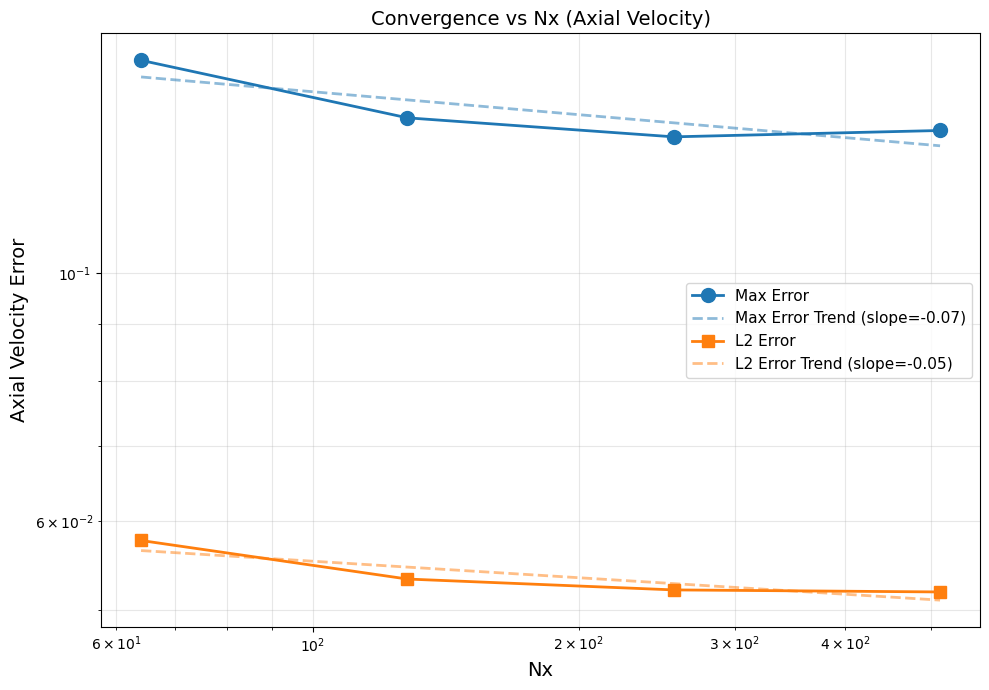

In [23]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.loglog(nx_array, u_axial_error_max, 'o-', linewidth=2, markersize=10, label='Max Error')
if len(nx_array) > 1:
    # Trend line for max error
    coeffs_max = np.polyfit(np.log(nx_array), np.log(u_axial_error_max), 1)
    nx_trend = np.logspace(np.log10(nx_array.min()), np.log10(nx_array.max()), 50)
    ax.loglog(nx_trend, np.exp(coeffs_max[1]) * nx_trend**coeffs_max[0], '--', alpha=0.5, linewidth=2, color='C0', label=f'Max Error Trend (slope={coeffs_max[0]:.2f})')

ax.loglog(nx_array, u_axial_error_l2, 's-', linewidth=2, markersize=8, label='L2 Error')
if len(nx_array) > 1:    
    # Trend line for L2 error
    coeffs_l2 = np.polyfit(np.log(nx_array), np.log(u_axial_error_l2), 1)
    ax.loglog(nx_trend, np.exp(coeffs_l2[1]) * nx_trend**coeffs_l2[0], '--', alpha=0.5, linewidth=2, color='C1', label=f'L2 Error Trend (slope={coeffs_l2[0]:.2f})')

ax.set_xlabel('Nx', fontsize=14)
ax.set_ylabel('Axial Velocity Error', fontsize=14)
ax.set_title('Convergence vs Nx (Axial Velocity)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig(f'{figureDir}/error_convergence.png', dpi=150)
plt.show()

Maximum axial velocity error across all cases: 1.548134e-01



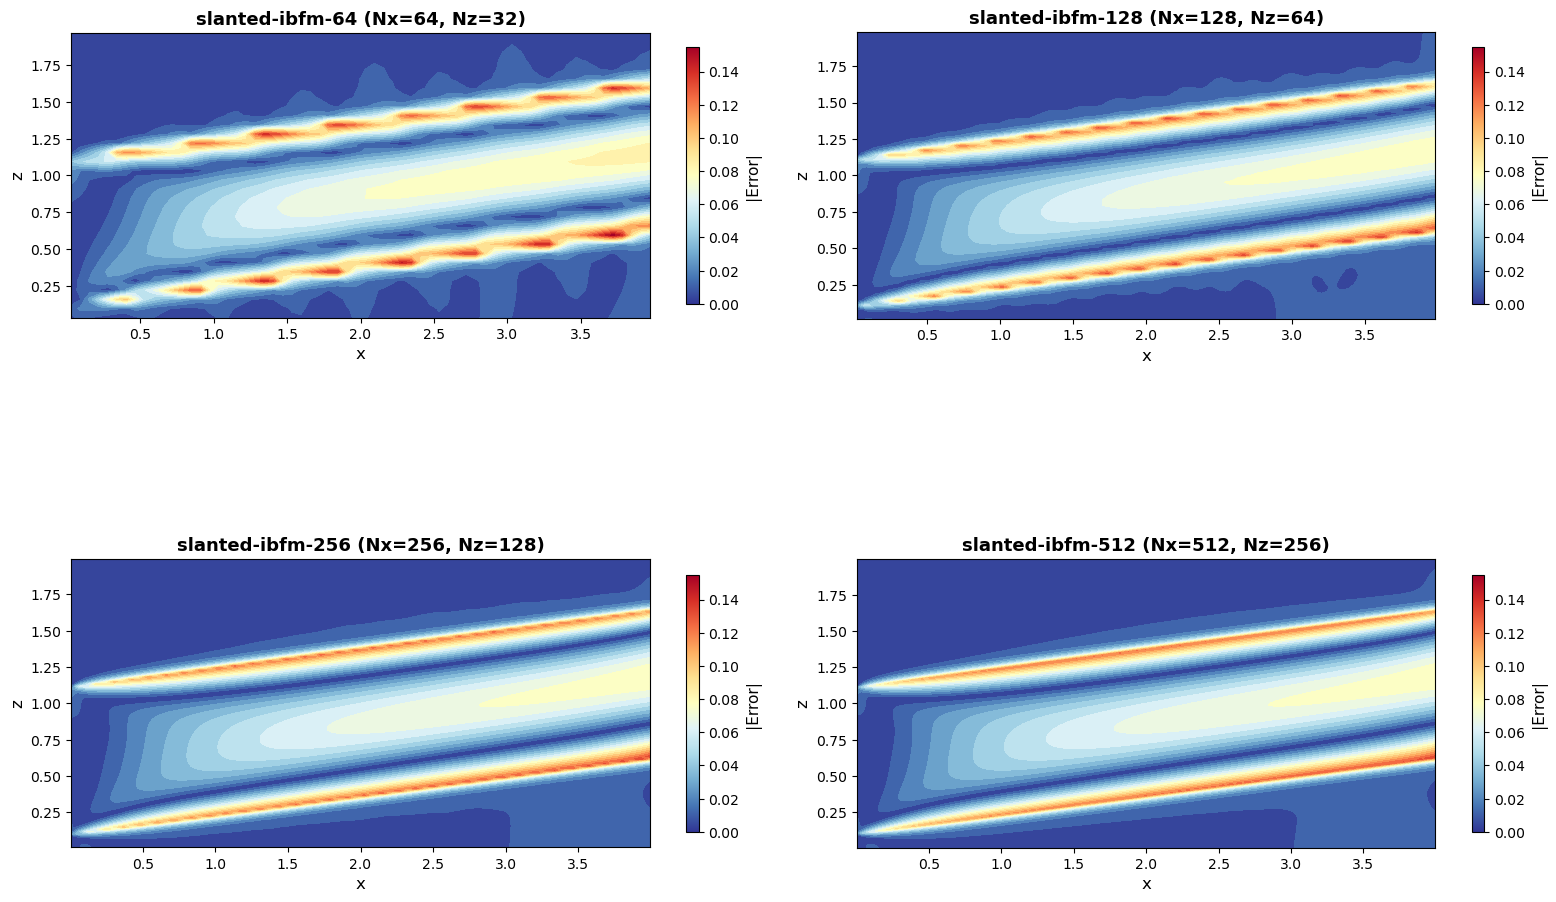

Axial velocity error field visualization complete (all colorbars use same scale)



In [27]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Find maximum error across all cases for consistent colorbar scaling
max_error_all = 0.0
for case_idx in range(nCases):
    j_mid = ny[case_idx] // 2
    
    # Extract 2D slices at midpoint
    u_2d = u[case_idx][:, j_mid, :]
    w_2d = w[case_idx][:, j_mid, :]
    u_exact_2d = u_exact[case_idx][:, j_mid, :]
    w_exact_2d = w_exact[case_idx][:, j_mid, :]
    
    # Calculate axial velocity errors
    u_axial_num = axial_velocity(u_2d, w_2d, theta_rad)
    u_axial_ana = axial_velocity(u_exact_2d, w_exact_2d, theta_rad)
    u_axial_err = u_axial_num - u_axial_ana
    
    max_error_all = max(max_error_all, np.abs(u_axial_err).max())

print(f'Maximum axial velocity error across all cases: {max_error_all:.6e}\n')

# Create a shared ScalarMappable to ensure all colorbars use the same scale
sm = ScalarMappable(cmap='RdYlBu_r', norm=Normalize(vmin=0, vmax=max_error_all))

for case_idx in range(4):
    ax = axes[case_idx]
    
    if case_idx < nCases:
        # Get axial velocity error field for this case
        j_mid = ny[case_idx] // 2
        
        # Extract 2D slices at midpoint
        u_2d = u[case_idx][:, j_mid, :]
        w_2d = w[case_idx][:, j_mid, :]
        u_exact_2d = u_exact[case_idx][:, j_mid, :]
        w_exact_2d = w_exact[case_idx][:, j_mid, :]
        
        # Calculate axial velocity errors
        u_axial_num = axial_velocity(u_2d, w_2d, theta_rad)
        u_axial_ana = axial_velocity(u_exact_2d, w_exact_2d, theta_rad)
        u_axial_err = u_axial_num - u_axial_ana
        
        # Create meshgrid for x and z
        X_mesh, Z_mesh = np.meshgrid(x[case_idx], z[case_idx], indexing='ij')
        
        # Plot contour with error magnitude using shared normalizer
        contour = ax.contourf(X_mesh, Z_mesh, np.abs(u_axial_err), levels=20, cmap='RdYlBu_r', norm=sm.norm)
        cbar = plt.colorbar(sm, ax=ax, shrink=0.4)
        cbar.set_label('|Error|', fontsize=11)
        
        ax.set_xlabel('x', fontsize=12)
        ax.set_ylabel('z', fontsize=12)
        ax.set_title(f'{valid_cases[case_idx]} (Nx={nx[case_idx]}, Nz={nz[case_idx]})', fontsize=13, fontweight='bold')
        ax.set_aspect('equal')
    else:
        # Leave empty subplots blank
        ax.axis('off')

plt.tight_layout()
plt.savefig(f'{figureDir}/error_field_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Axial velocity error field visualization complete (all colorbars use same scale)\n')

## Axial Velocity - Wall Error Analysis

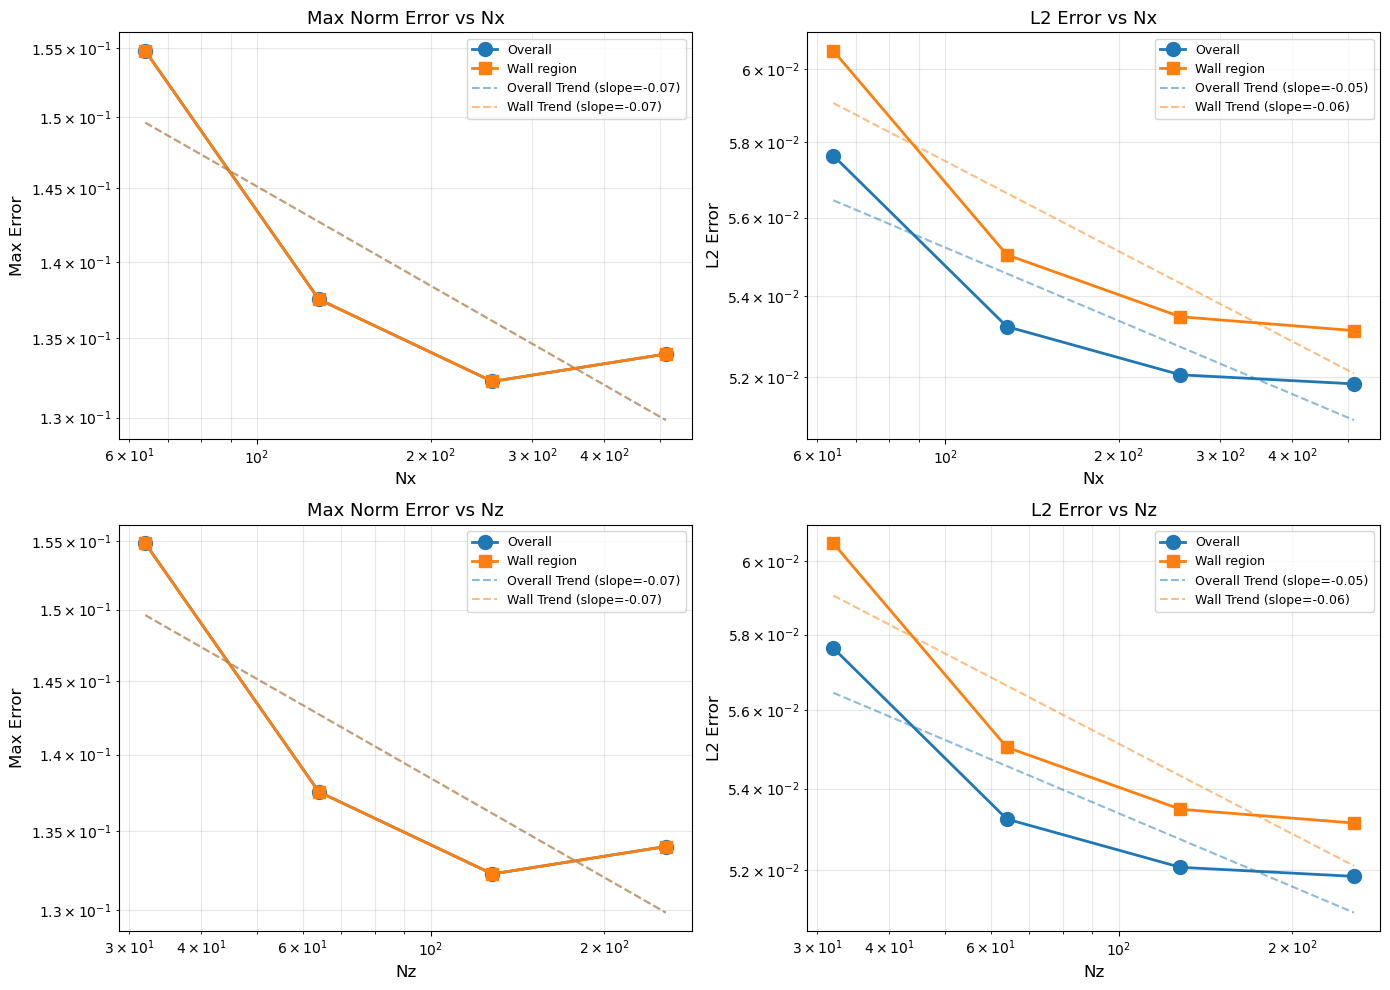

Wall error analysis complete

CONVERGENCE RATE ANALYSIS (Slopes)
Error Type                Region               vs Nx           vs Nz          
Max Error                 Overall              -0.07           -0.07          
Max Error                 Wall                 -0.07           -0.07          
L2 Error                  Overall              -0.05           -0.05          
L2 Error                  Wall                 -0.06           -0.06          
AXIAL VELOCITY ERROR SUMMARY
Case                 Grid            Max Error (Overall)  L2 Error (Overall)   Max Error (Wall)     L2 Error (Wall)     
slanted-ibfm-64      64 x 32       1.548134e-01         5.763493e-02         1.548134e-01         6.050738e-02        
slanted-ibfm-128     128 x 64       1.375350e-01         5.324059e-02         1.375350e-01         5.504276e-02        
slanted-ibfm-256     256 x 128      1.322592e-01         5.206305e-02         1.322592e-01         5.348397e-02        
slanted-ibfm-512     512 x 256 

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Max Error vs Nx
ax = axes[0, 0]
ax.loglog(nx_array, u_axial_error_max, 'o-', linewidth=2, markersize=10, label='Overall')
ax.loglog(nx_array, u_axial_error_max_wall, 's-', linewidth=2, markersize=8, label='Wall region')
if len(nx_array) > 1:
    coeffs_max_overall = np.polyfit(np.log(nx_array), np.log(u_axial_error_max), 1)
    coeffs_max_wall = np.polyfit(np.log(nx_array), np.log(u_axial_error_max_wall), 1)
    nx_trend = np.logspace(np.log10(nx_array.min()), np.log10(nx_array.max()), 50)
    ax.loglog(nx_trend, np.exp(coeffs_max_overall[1]) * nx_trend**coeffs_max_overall[0], '--', alpha=0.5, linewidth=1.5, color='C0', label=f'Overall Trend (slope={coeffs_max_overall[0]:.2f})')
    ax.loglog(nx_trend, np.exp(coeffs_max_wall[1]) * nx_trend**coeffs_max_wall[0], '--', alpha=0.5, linewidth=1.5, color='C1', label=f'Wall Trend (slope={coeffs_max_wall[0]:.2f})')
ax.set_xlabel('Nx', fontsize=12)
ax.set_ylabel('Max Error', fontsize=12)
ax.set_title('Max Norm Error vs Nx', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which='both')

# L2 Error vs Nx
ax = axes[0, 1]
ax.loglog(nx_array, u_axial_error_l2, 'o-', linewidth=2, markersize=10, label='Overall')
ax.loglog(nx_array, u_axial_error_l2_wall, 's-', linewidth=2, markersize=8, label='Wall region')
if len(nx_array) > 1:
    coeffs_l2_overall = np.polyfit(np.log(nx_array), np.log(u_axial_error_l2), 1)
    coeffs_l2_wall = np.polyfit(np.log(nx_array), np.log(u_axial_error_l2_wall), 1)
    nx_trend = np.logspace(np.log10(nx_array.min()), np.log10(nx_array.max()), 50)
    ax.loglog(nx_trend, np.exp(coeffs_l2_overall[1]) * nx_trend**coeffs_l2_overall[0], '--', alpha=0.5, linewidth=1.5, color='C0', label=f'Overall Trend (slope={coeffs_l2_overall[0]:.2f})')
    ax.loglog(nx_trend, np.exp(coeffs_l2_wall[1]) * nx_trend**coeffs_l2_wall[0], '--', alpha=0.5, linewidth=1.5, color='C1', label=f'Wall Trend (slope={coeffs_l2_wall[0]:.2f})')
ax.set_xlabel('Nx', fontsize=12)
ax.set_ylabel('L2 Error', fontsize=12)
ax.set_title('L2 Error vs Nx', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which='both')

# Max Error vs Nz
ax = axes[1, 0]
ax.loglog(nz_array, u_axial_error_max, 'o-', linewidth=2, markersize=10, label='Overall')
ax.loglog(nz_array, u_axial_error_max_wall, 's-', linewidth=2, markersize=8, label='Wall region')
if len(nz_array) > 1:
    coeffs_max_overall_z = np.polyfit(np.log(nz_array), np.log(u_axial_error_max), 1)
    coeffs_max_wall_z = np.polyfit(np.log(nz_array), np.log(u_axial_error_max_wall), 1)
    nz_trend = np.logspace(np.log10(nz_array.min()), np.log10(nz_array.max()), 50)
    ax.loglog(nz_trend, np.exp(coeffs_max_overall_z[1]) * nz_trend**coeffs_max_overall_z[0], '--', alpha=0.5, linewidth=1.5, color='C0', label=f'Overall Trend (slope={coeffs_max_overall_z[0]:.2f})')
    ax.loglog(nz_trend, np.exp(coeffs_max_wall_z[1]) * nz_trend**coeffs_max_wall_z[0], '--', alpha=0.5, linewidth=1.5, color='C1', label=f'Wall Trend (slope={coeffs_max_wall_z[0]:.2f})')
ax.set_xlabel('Nz', fontsize=12)
ax.set_ylabel('Max Error', fontsize=12)
ax.set_title('Max Norm Error vs Nz', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which='both')

# L2 Error vs Nz
ax = axes[1, 1]
ax.loglog(nz_array, u_axial_error_l2, 'o-', linewidth=2, markersize=10, label='Overall')
ax.loglog(nz_array, u_axial_error_l2_wall, 's-', linewidth=2, markersize=8, label='Wall region')
if len(nz_array) > 1:
    coeffs_l2_overall_z = np.polyfit(np.log(nz_array), np.log(u_axial_error_l2), 1)
    coeffs_l2_wall_z = np.polyfit(np.log(nz_array), np.log(u_axial_error_l2_wall), 1)
    nz_trend = np.logspace(np.log10(nz_array.min()), np.log10(nz_array.max()), 50)
    ax.loglog(nz_trend, np.exp(coeffs_l2_overall_z[1]) * nz_trend**coeffs_l2_overall_z[0], '--', alpha=0.5, linewidth=1.5, color='C0', label=f'Overall Trend (slope={coeffs_l2_overall_z[0]:.2f})')
    ax.loglog(nz_trend, np.exp(coeffs_l2_wall_z[1]) * nz_trend**coeffs_l2_wall_z[0], '--', alpha=0.5, linewidth=1.5, color='C1', label=f'Wall Trend (slope={coeffs_l2_wall_z[0]:.2f})')
ax.set_xlabel('Nz', fontsize=12)
ax.set_ylabel('L2 Error', fontsize=12)
ax.set_title('L2 Error vs Nz', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig(f'{figureDir}/wall_error_analysis.png', dpi=150)
plt.show()
print('Wall error analysis complete\n')

# Print trend slopes
print('='*90)
print('CONVERGENCE RATE ANALYSIS (Slopes)')
print('='*90)
if len(nx_array) > 1:
    coeffs_max_overall = np.polyfit(np.log(nx_array), np.log(u_axial_error_max), 1)
    coeffs_max_wall = np.polyfit(np.log(nx_array), np.log(u_axial_error_max_wall), 1)
    coeffs_l2_overall = np.polyfit(np.log(nx_array), np.log(u_axial_error_l2), 1)
    coeffs_l2_wall = np.polyfit(np.log(nx_array), np.log(u_axial_error_l2_wall), 1)
    coeffs_max_overall_z = np.polyfit(np.log(nz_array), np.log(u_axial_error_max), 1)
    coeffs_max_wall_z = np.polyfit(np.log(nz_array), np.log(u_axial_error_max_wall), 1)
    coeffs_l2_overall_z = np.polyfit(np.log(nz_array), np.log(u_axial_error_l2), 1)
    coeffs_l2_wall_z = np.polyfit(np.log(nz_array), np.log(u_axial_error_l2_wall), 1)
    
    print(f'{"Error Type":<25} {"Region":<20} {"vs Nx":<15} {"vs Nz":<15}')
    print('='*90)
    print(f'{"Max Error":<25} {"Overall":<20} {coeffs_max_overall[0]:<15.2f} {coeffs_max_overall_z[0]:<15.2f}')
    print(f'{"Max Error":<25} {"Wall":<20} {coeffs_max_wall[0]:<15.2f} {coeffs_max_wall_z[0]:<15.2f}')
    print(f'{"L2 Error":<25} {"Overall":<20} {coeffs_l2_overall[0]:<15.2f} {coeffs_l2_overall_z[0]:<15.2f}')
    print(f'{"L2 Error":<25} {"Wall":<20} {coeffs_l2_wall[0]:<15.2f} {coeffs_l2_wall_z[0]:<15.2f}')
    print('='*90)

# Error Summary
print('='*90)
print('AXIAL VELOCITY ERROR SUMMARY')
print('='*90)
print(f'{"Case":<20} {"Grid":<15} {"Max Error (Overall)":<20} {"L2 Error (Overall)":<20} {"Max Error (Wall)":<20} {"L2 Error (Wall)":<20}')
print('='*90)
for i in range(nCases):
    print(f'{valid_cases[i]:<20} {nx[i]} x {nz[i]:<8} {u_axial_error_max[i]:<20.6e} {u_axial_error_l2[i]:<20.6e} {u_axial_error_max_wall[i]:<20.6e} {u_axial_error_l2_wall[i]:<20.6e}')
print('='*90)

## Velocity Profile Comparison

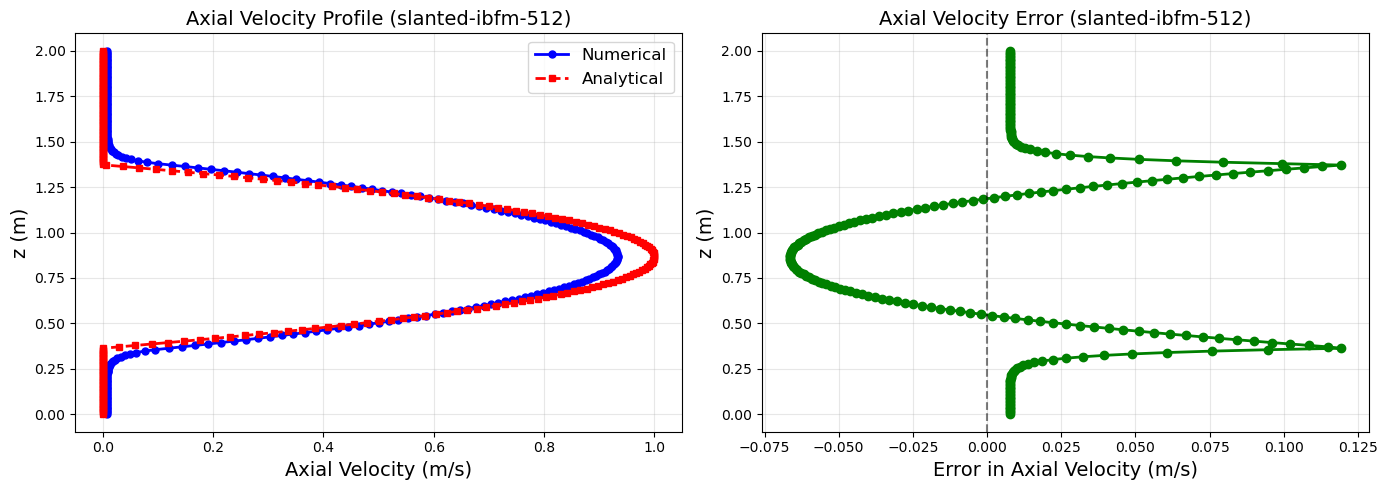

In [29]:
case_finest = nCases - 1
j_mid = ny[case_finest] // 2
i_mid = nx[case_finest] // 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Extract axial velocity components at midpoint slice
u_2d = u[case_finest][:, j_mid, :]
w_2d = w[case_finest][:, j_mid, :]
u_exact_2d = u_exact[case_finest][:, j_mid, :]
w_exact_2d = w_exact[case_finest][:, j_mid, :]

# Compute axial velocities
u_axial_num = axial_velocity(u_2d, w_2d, theta_rad)
u_axial_ana = axial_velocity(u_exact_2d, w_exact_2d, theta_rad)

ax = axes[0]
ax.plot(u_axial_num[i_mid, :], z[case_finest], 'b-', linewidth=2, marker='o', markersize=5, label='Numerical')
ax.plot(u_axial_ana[i_mid, :], z[case_finest], 'r--', linewidth=2, marker='s', markersize=5, label='Analytical')
ax.set_xlabel('Axial Velocity (m/s)', fontsize=14)
ax.set_ylabel('z (m)', fontsize=14)
ax.set_title(f'Axial Velocity Profile ({valid_cases[case_finest]})', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

ax = axes[1]
velocity_error = u_axial_num[i_mid, :] - u_axial_ana[i_mid, :]
ax.plot(velocity_error, z[case_finest], 'g-', linewidth=2, marker='o', markersize=6)
ax.axvline(x=0, color='k', linestyle='--', alpha=0.5)
ax.set_xlabel('Error in Axial Velocity (m/s)', fontsize=14)
ax.set_ylabel('z (m)', fontsize=14)
ax.set_title(f'Axial Velocity Error ({valid_cases[case_finest]})', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{figureDir}/velocity_profile_comparison.png', dpi=150)
plt.show()